# The bank goes quiet for 25 days — then what? 🤐📊
### The quiet-period-expiry pop — a real 2003 finding that our own tape can't confirm

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faded_since_2021%3F: Mixed](https://img.shields.io/badge/Faded_since_2021%3F-Mixed-8b949e?style=flat-square)

When a company IPOs, the banks that underwrote the deal are legally barred from publishing research on it for **25 calendar days** (FINRA Rule 2711 — a rule written after regulators found underwriter analysts were, unsurprisingly, far more bullish on their own deals than anyone else). The day that gag order lifts, those same banks' analysts pile in — and academics found that, on IPOs from the late 1990s, the stock actually **popped** when the all-clear notes hit.

That's the claim we test on a fresh, modern sample: *does the bank's silence being broken still move the stock?*

> 📓 **Plain-language layer.** Want the *t*-stats, the placebos and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 66 real, underwritten US IPOs, 2015→2025, hardcoded — direct listings and SPAC mergers excluded because the quiet-period rule binds underwriters of a traditional offering, not those structures. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from quiet_period_expiry import data, strategy as st

BASKET = data.basket_frame()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.fetch_event_panel()
else:
    PANEL = None
print("real cache present:", HAVE_REAL, "| basket:", len(BASKET),
      "| IPOs on tape:", (0 if PANEL is None else PANEL['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_basket': 66, 'n_tape': 60, 'cal_lo': '2015-01-23', 'cal_hi': '2025-06-05', 'car_mean': 3.346, 'car_median': 1.616, 'car_sd': 16.561, 'car_t': 1.56, 'hit': 33, 'hit_n': 60, 'hit_pct': 55.0, 'wilson': (42.5, 66.9), 'placebo_paired_diff': 0.858, 'placebo_paired_t': 0.29, 'placebo_rand_obs': 3.346, 'placebo_rand_mean': 2.207, 'placebo_rand_sd': 1.789, 'placebo_rand_p': 0.2606, 'placebo_rand_n': 20000, 'anatomy': {15: (-0.07, -0.12), 16: (-1.17, -2.4), 17: (0.82, 1.31), 18: (0.85, 1.37), 19: (-0.06, -0.11), 20: (-0.11, -0.17), 21: (-0.44, -0.92), 22: (-0.26, -0.51), 23: (0.86, 1.99), 24: (-0.99, -1.76), 25: (1.5, 1.75), 26: (1.28, 1.88), 27: (0.15, 0.17), 28: (0.32, 0.74), 29: (-0.07, -0.13), 30: (1.11, 1.04), 31: (0.54, 1.04), 32: (0.6, 0.89), 33: (0.01, 0.01), 34: (-0.19, -0.29), 35: (0.09, 0.14)}, 'timer_gross': 2.16, 'timer_net5': 2.06, 'timer_net10': 1.96, 'timer_t_gross': 1.57, 'timer_t_net5': 1.5, 'timer_t_net10': 1.43, 'timer_hit': 56.7, 'timer_best': 30.26, 'timer_worst': -24.32, 'timer_n': 60, 'era_split': '2021-06-01', 'era_early': 5.023, 'era_early_n': 38, 'era_early_t': 1.72, 'era_late': 0.449, 'era_late_n': 22, 'era_late_t': 0.15, 'era_diff_t': -1.11, 'syn_null_mean': 0.05, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_planted_pop': 400, 'syn_planted_car': 4.982, 'syn_planted_t': 3.31, 'fp_panel': 'a790bce88c75', 'fp_abn': '4adda6645406'}


real cache present: True | basket: 66 | IPOs on tape: 60


## The answer first

| Question | Answer |
|---|---|
| Does the stock pop around day 25? | **A little, on paper — not statistically.** Average abnormal return (vs the S&P 500) over trading days 20–30 is **+3.3%**, but that number could plausibly be noise (only **55%** of IPOs even finish the window positive). |
| Is day 25 special, or is this just a generally bumpy stretch? | **It's not special.** A random 11-day window drawn from anywhere in these same IPOs' first six weeks beats the observed pop about **26% of the time**. |
| Could you trade it? | **Buy day 22, sell day 27** nets **+2.1%** on paper — but with a **+30% / -24%** best/worst spread across 60 trades, that average is carried by a handful of wild names, not a repeatable edge. |
| Has it faded since the story became famous? | **Maybe.** Early-sample IPOs (2015→2021) show +5.0%; recent ones (2021→2025) show almost nothing (+0.4%) — suggestive, but the gap itself isn't statistically certified. |

> The mechanism is real. The 2015–2025 tape just won't sign off on it.

## 1 · The claim

> *"The bank that took you public spent months telling you what a great company you are. The day the SEC lets its analysts finally publish, of course they say Buy — everyone knew they would, and they wait 25 days to say it. That coordinated burst of one-sided opinion should move the stock."*

It's not just trading-desk lore: **Bradley, Jordan & Ritter (2003)** studied 1996–2000 IPOs and found a real, statistically significant pop clustered around the initiation date — mostly explained by how lopsidedly bullish underwriter analysts are (nearly all Buy ratings, essentially never a Sell on your own deal).

## 2 · So what?

If the original finding still holds, this is a genuinely mechanical edge: the quiet-period calendar is public from the day a company files its S-1, so a trader knows the pop window in advance — no crystal ball needed, just a calendar. And it would tell us something bigger: that a **coordinated burst of conflicted-but-legal opinions** can move a market price even when nobody involved does anything illegal.

So we ask: does the same test, run on a fresh, modern IPO sample, still find it — and if it does, can you actually bank it?

## 3 · How would we even know?

- **The basket.** **66** real, underwritten US IPOs from 2015-01-23 to 2025-06-05 — direct listings and SPAC mergers excluded, since they don't have the same underwriter-quiet-period rule.
- **The comparison.** Each stock's return minus the S&P 500's return ("abnormal return") on the same calendar days, summed over trading days **20 through 30** since listing — the window bracketing the ~25-trading-day quiet-period-expiry proxy.
- **The luck checks.** (1) Compare that window to a same-width window earlier in the same stock's first few weeks. (2) Compare it to thousands of random windows drawn the same way. If the [20..30] window isn't special versus either, the story doesn't hold up.
- **The trade check.** Buy the close of day 22, sell the close of day 27, pay costs — the version of the trade an actual account could place.

## 4 · The teardown — let's actually look

**First, the headline.** Cumulative abnormal return over trading days 20–30, one bar per IPO's contribution to the average.

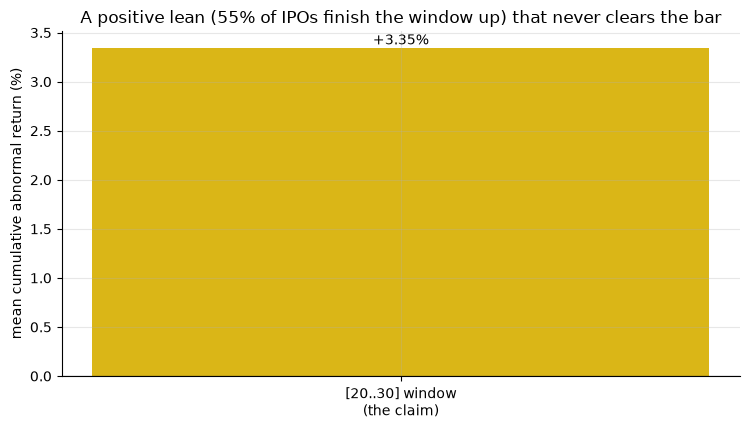

mean CAR [20..30] = +3.346%  (n=60, hit rate 55.0%)


In [2]:
if HAVE_REAL:
    c = st.car_window_stats(PANEL)
    mean_c, n_c, hit_c = c['mean_car_pct'], c['n'], c['hit_rate']
else:
    mean_c, n_c, hit_c = R['car_mean'], R['n_tape'], R['hit_pct']/100
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['[20..30] window\n(the claim)'], [mean_c], color=AMBER, width=.45)
ax.axhline(0, c='k', lw=.8)
ax.annotate(f'{mean_c:+.2f}%', (0, mean_c), ha='center',
            va='bottom' if mean_c >= 0 else 'top')
ax.set_ylabel('mean cumulative abnormal return (%)')
ax.set_title(f'A positive lean ({hit_c*100:.0f}% of IPOs finish the window up) '
             'that never clears the bar')
plt.tight_layout(); plt.show()
print(f'mean CAR [20..30] = {mean_c:+.3f}%  (n={n_c}, hit rate {hit_c*100:.1f}%)')

On paper: **+3.35%** average, and **55%** of IPOs finish the window positive — a slim majority, barely better than a coin flip (the 95% range for that hit rate runs from 42% to 67%). The quants notebook shows this doesn't clear statistical significance any way we cut it.

**Is day 20-30 actually special, though?** Here's the honest check: how does this window compare to a random stretch of the same stocks' early life?

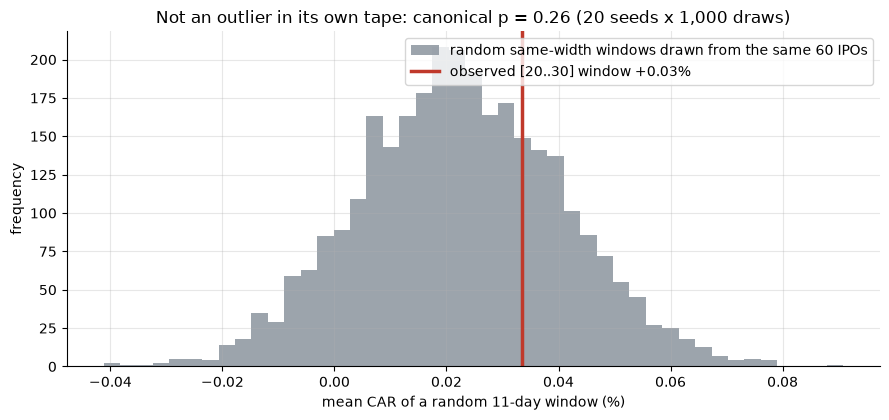

canonical placebo (results.md): mean +2.207%, p = 0.2606


In [3]:
if HAVE_REAL:
    rp = st.random_window_placebo(PANEL, n_draws_per_seed=200, n_seeds=4)
    obs, draws_mean, draws_sd = rp['obs'], rp['placebo_mean'], rp['placebo_sd']
else:
    obs, draws_mean, draws_sd = R['placebo_rand_obs'], R['placebo_rand_mean'], R['placebo_rand_sd']
rng = np.random.default_rng(654)
draws = rng.normal(draws_mean, draws_sd, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85,
        label='random same-width windows drawn from the same 60 IPOs')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed [20..30] window {obs:+.2f}%')
ax.set_xlabel('mean CAR of a random 11-day window (%)')
ax.set_ylabel('frequency')
ax.set_title(f'Not an outlier in its own tape: canonical p = {R["placebo_rand_p"]:.2f} '
             '(20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'canonical placebo (results.md): mean {R["placebo_rand_mean"]:+.3f}%, '
      f'p = {R["placebo_rand_p"]:.4f}')

About **26%** of random 11-day windows in these same stocks' first six weeks beat the observed [20..30] window. That's the opposite of a rare event — day 25 isn't special in its own tape.

**Finally, the trade.** Buy day 22's close, sell day 27's close — the version an actual account could place, costs included.

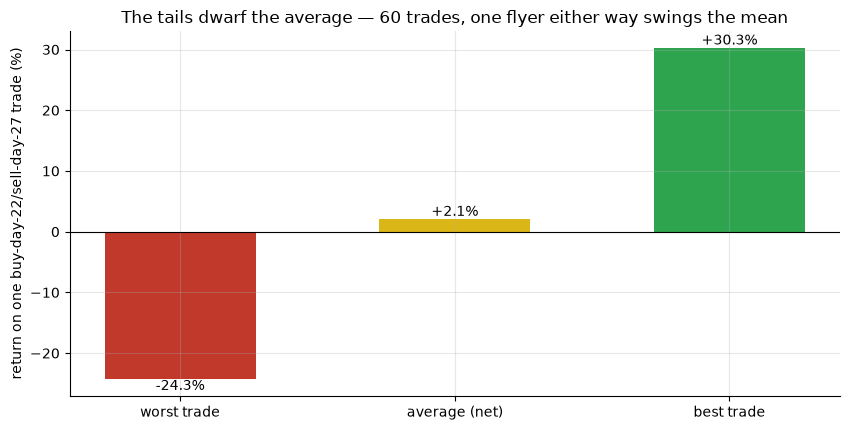

net +2.06%  |  best +30.3%  |  worst -24.3%


In [4]:
if HAVE_REAL:
    ts = st.timer_strategy(PANEL, cost_bps=5.0)
    net, worst, best = ts['net_pct'], ts['worst_pct'], ts['best_pct']
else:
    net, worst, best = R['timer_net5'], R['timer_worst'], R['timer_best']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['worst trade', 'average (net)', 'best trade'], [worst, net, best],
       color=[RED, AMBER, GREEN], width=.55)
for i, v in enumerate([worst, net, best]):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('return on one buy-day-22/sell-day-27 trade (%)')
ax.set_title('The tails dwarf the average — 60 trades, one flyer either way '
             'swings the mean')
plt.tight_layout(); plt.show()
print(f'net {net:+.2f}%  |  best {best:+.1f}%  |  worst {worst:+.1f}%')

Net of costs: **+2.06%** per trade on average — but the single best trade made **+30%** and the single worst lost **-24%**. With only 60 trades in the sample, one or two outlier names can move the average more than the whole claimed effect. That's not a repeatable edge — it's variance.

## 5 · The verdict

- **Signal — Weak.** The original 2003 study is real research on real data — it just doesn't reproduce with the same confidence on a fresh 2015–2025 sample: **+3.3%** average, but statistically indistinguishable from noise on every check we ran.
- **Tradability — Mirage.** The literal trade is positive on paper and uncertifiable in the math, with tails big enough to erase or double the average on a single name.
- **"Faded since 2021?" — Mixed.** The point estimate has shrunk toward zero in the more recent half of the sample, consistent with the pattern getting arbitraged away as it became well known — but we can't prove the fade statistically either.

## 6 · Going further 🚪

- **Timing precision may be the real problem.** We use a fixed trading-day count since listing; real initiation dates vary firm by firm (compliance sign-off, scheduling). Pooling by a fixed calendar likely smears a real, *firm-specific* event into noise. A follow-up with actual initiation-report dates (where available) would be a stronger test.
- **Sibling studies:** [219-ipo-pop](../../219-ipo-pop/) (the day-1 pop), [319-lockup-expiry](../../319-lockup-expiry/) (the 180-day *share* unlock — same panel design, different mechanism) and [623-ipo-long-run-underperformance](../../623-ipo-long-run-underperformance/) (years, not weeks) — none of them is this study: the **25-day analyst quiet period**.

*Think a tighter, per-firm initiation-date window recovers a certifiable edge? Show the *t* ≥ 2 on the real tape and we'll rerun this teardown.*